# Segmentación de Clientes

### 1. Leer el archivo Retail_Invoices.xlsx y realizar un análisis de calidad de datos, para definir la calidad de la data entregada considerando valores anómalos, valores faltantes, etc. Limpia lo que sea necesario y realiza un análisis exploratorio de los datos considerando gráficos de distribuciones y correlaciones entre estos


In [1]:
# importar librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import io
import warnings
warnings.filterwarnings('ignore')

# Librerías para clustering
from IPython.display import display
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import pairwise_distances

# Cargamos el dataset
df = pd.read_excel("Retail_Invoices.xlsx")

### Funcion para el análisis del dataset 

In [2]:
# Análisis general del dataset
def analisis_general(df):   # función para realizar un análisis general del dataset

    buffer = io.StringIO()  # creamos un buffer para capturar la salida de info()
    df.info(buf=buffer)     # obtenemos la información del dataframe y la guardamos en el buffer
    info_str = buffer.getvalue()    # convertimos el contenido del buffer a una cadena de texto

    negativos_quantity = (df["Quantity"] < 0).sum() # contamos cuántos valores negativos hay en la columna "Quantity"
    negativos_price = (df["price_total"] < 0).sum() # contamos cuántos valores negativos hay en la columna "price_total"

    # Imprimimos los resultados del análisis general
    print("ANÁLISIS GENERAL DEL DATASET\n")  

    print("🔹 Primeras filas del dataset:")
    display(df.head())

    print("\n🔹 Dimensiones:")
    print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")

    print("\n🔹 Información general:")
    df.info()

    print("\n🔹 Tipos de datos:")
    display(df.dtypes)

    print("\n🔹 Valores nulos:")
    display(df.isnull().sum())

    print("\n🔹 Filas duplicadas:")
    print(df.duplicated().sum())

    print("\n🔹 Estadísticas descriptivas:")
    display(df.describe())

    print("\n🔹 Métricas clave:")
    print(f"Clientes únicos: {df['CustomerID'].nunique()}")
    print(f"Transacciones únicas: {df['InvoiceNo'].nunique()}")

    print("\n🔹 Valores negativos detectados:")
    print(f"Quantity negativos: {negativos_quantity}")
    print(f"price_total negativos: {negativos_price}")

In [3]:
# Ejecutamos el análisis general
analisis_general(df)

ANÁLISIS GENERAL DEL DATASET

🔹 Primeras filas del dataset:


,InvoiceNo,InvoiceDate,CustomerID,Quantity,price_total,StockCode
0,536365,2010-12-01,17850,40,139.12,7
1,536366,2010-12-01,17850,12,22.20,2
2,536367,2010-12-01,13047,83,278.73,12
3,536368,2010-12-01,13047,15,70.05,4
4,536369,2010-12-01,13047,3,17.85,1



🔹 Dimensiones:
Filas: 22190, Columnas: 6

🔹 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22190 entries, 0 to 22189
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    22190 non-null  object        
 1   InvoiceDate  22190 non-null  datetime64[ns]
 2   CustomerID   22190 non-null  int64         
 3   Quantity     22190 non-null  int64         
 4   price_total  22190 non-null  float64       
 5   StockCode    22190 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 1.0+ MB

🔹 Tipos de datos:


InvoiceNo              object
InvoiceDate    datetime64[ns]
CustomerID              int64
Quantity                int64
price_total           float64
StockCode               int64
dtype: object


🔹 Valores nulos:


InvoiceNo      0
InvoiceDate    0
CustomerID     0
Quantity       0
price_total    0
StockCode      0
dtype: int64


🔹 Filas duplicadas:
0

🔹 Estadísticas descriptivas:


,InvoiceDate,CustomerID,Quantity,price_total,StockCode
count,22190,22190.000000,22190.000000,22190.000000,22190.000000
mean,2011-06-29 05:59:15.223073536,15238.498738,221.130599,374.045327,18.333889
min,2010-12-01 00:00:00,12346.000000,-80995.000000,-168469.600000,1.000000
25%,2011-03-29 00:00:00,13755.000000,30.000000,87.962500,3.000000
50%,2011-07-08 00:00:00,15136.000000,120.000000,241.505000,12.000000
75%,2011-10-10 00:00:00,16746.000000,254.000000,418.022500,24.000000
max,2011-12-09 00:00:00,18287.000000,80995.000000,168469.600000,542.000000
std,NaN,1733.149624,1170.215301,2018.482869,23.892111



🔹 Métricas clave:
Clientes únicos: 4372
Transacciones únicas: 22190

🔹 Valores negativos detectados:
Quantity negativos: 3654
price_total negativos: 3654


Se realizó una revisión inicial del dataset para identificar posibles problemas de calidad de datos.
No se detectaron valores nulos en las variables principales, lo que indica una buena completitud de la información.
Sin embargo, se observaron valores negativos en variables como Quantity y price_total, lo cual puede indicar devoluciones, anulaciones o errores en el registro.
Además, variables como InvoiceNo y CustomerID corresponden a identificadores y no serán utilizadas como variables analíticas en el modelamiento.

In [4]:
# Creamos una copia del dataframe para realizar la limpieza de datos
df_cleaner = df.copy()

# Eliminación de valores anómalos
df_cleaner = df_cleaner[df_cleaner["Quantity"] > 0]     # eliminamos filas donde "Quantity" es menor o igual a 0
df_cleaner = df_cleaner[df_cleaner["price_total"] > 0]   # eliminamos filas donde "price_total" es menor o igual a 0

# Asegurar tipo fecha
df_cleaner["InvoiceDate"] = pd.to_datetime(df_cleaner["InvoiceDate"])   # convertimos la columna "InvoiceDate" a tipo datetime

# Asegurar tipo numérico
df_cleaner["InvoiceNo"] = df_cleaner["InvoiceNo"].astype("int64")   # convertimos la columna "InvoiceNo" a tipo int64

# Imprimimos las dimensiones del dataframe original y del dataframe limpio para comparar
print("Dimensión original:", df.shape)
print("Dimensión después de limpieza:", df_cleaner.shape)

Dimensión original: (22190, 6)
Dimensión después de limpieza: (18532, 6)


Se eliminaron registros con valores negativos en Quantity y price_total, ya que no representan compras válidas para el análisis de comportamiento de clientes.
Estos valores podrían corresponder a devoluciones o errores de registro, por lo que se excluyen para evitar sesgos en la segmentación.

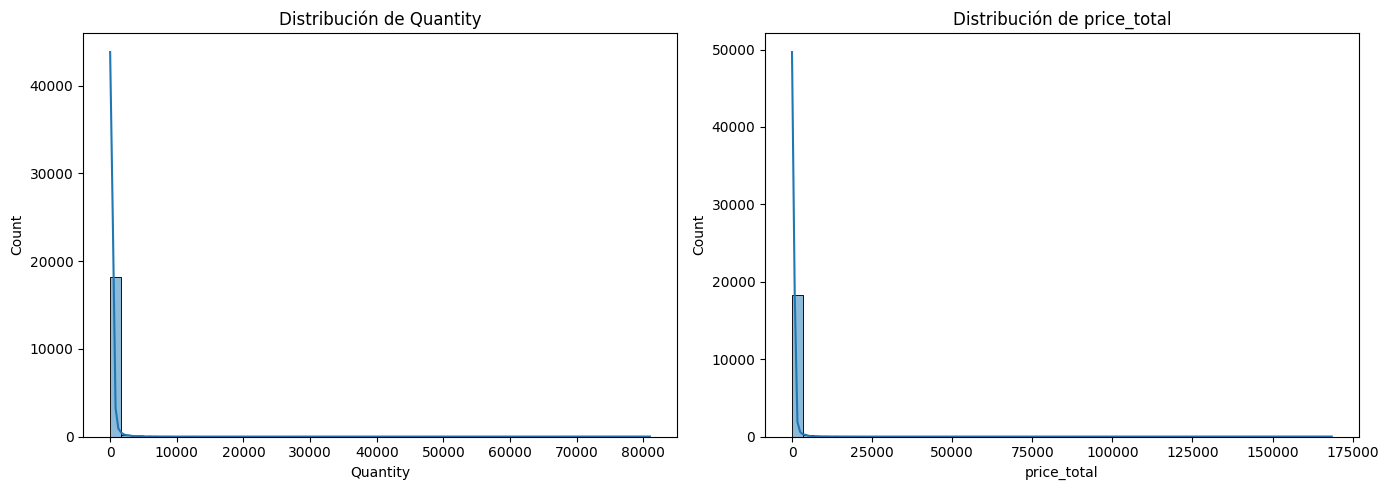

In [5]:
# Análisis univariado
fig, axes = plt.subplots(1, 2, figsize=(14,5))

sns.histplot(df_cleaner["Quantity"], bins=50, kde=True, ax=axes[0])     # graficamos la distribución de la columna "Quantity" utilizando un histograma con una curva de densidad (kde)
axes[0].set_title("Distribución de Quantity")                           # establecemos el título del gráfico

sns.histplot(df_cleaner["price_total"], bins=50, kde=True, ax=axes[1])  # graficamos la distribución de la columna "price_total" utilizando un histograma con una curva de densidad (kde)
axes[1].set_title("Distribución de price_total")                        # establecemos el título del gráfico

plt.tight_layout()  # ajustamos el diseño para evitar solapamientos
plt.show()          # mostramos los gráficos

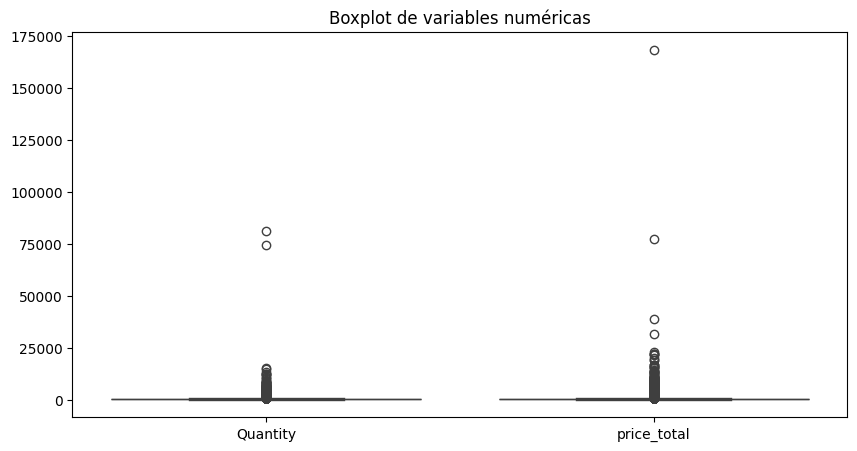

In [6]:
# Análisis bivariado
plt.figure(figsize=(10,5))                                  # definimos el tamaño del gráfico
sns.boxplot(data=df_cleaner[["Quantity", "price_total"]])   # graficamos un boxplot para visualizar la relación entre "Quantity" y "price_total"
plt.title("Boxplot de variables numéricas")                 # establecemos el título del gráfico
plt.show()                                                  # mostramos el gráfico

Se identificaron valores extremos en las variables Quantity y price_total. Sin embargo, estos no seran eliminados, ya que corresponden a transacciones reales de alto volumen. En lugar de excluirlos, se mantienen para preservar la información del negocio y posteriormente se aplicaran transformaciones logarítmicas para reducir su impacto en el modelo.

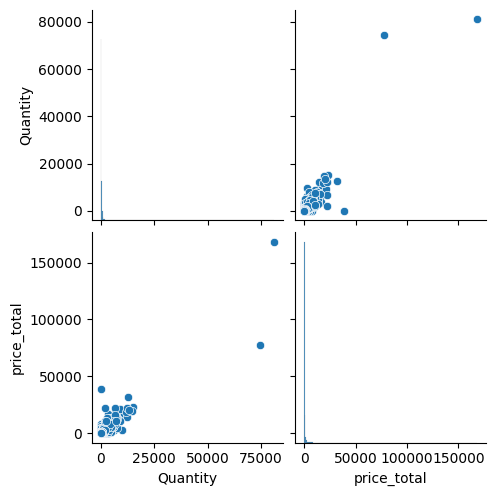

In [7]:
# Gráficos de dispersión
sns.pairplot(df_cleaner[["Quantity", "price_total"]])  # Crea gráficos de dispersión para las variables seleccionadas.
# muestra el gráfico
plt.show()

Las variables Quantity y price_total presentan distribuciones asimétricas con sesgo hacia la derecha, lo cual es común en datos de retail.
Se observa la presencia de valores extremos, indicando que existen algunas compras de gran volumen en comparación con la mayoría de las transacciones.

Fecha mínima: 2010-12-01 00:00:00
Fecha máxima: 2011-12-09 00:00:00


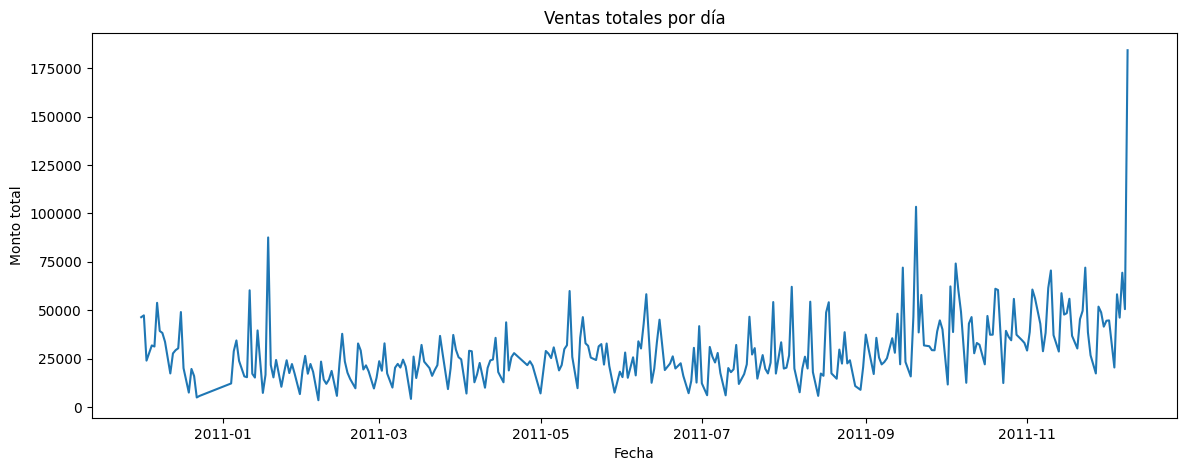

In [8]:
# Análisis temporal
print("Fecha mínima:", df_cleaner["InvoiceDate"].min()) # imprimimos la fecha mínima de la columna "InvoiceDate"
print("Fecha máxima:", df_cleaner["InvoiceDate"].max()) # imprimimos la fecha máxima de la columna "InvoiceDate"

ventas_por_dia = df_cleaner.groupby(df_cleaner["InvoiceDate"].dt.date)["price_total"].sum() # agrupamos el dataframe por fecha (sin hora) y sumamos el "price_total" para obtener las ventas totales por día

plt.figure(figsize=(14,5))          # definimos el tamaño del gráfico
ventas_por_dia.plot()               # graficamos las ventas totales por día utilizando un gráfico de líneas
plt.title("Ventas totales por día") # establecemos el título del gráfico
plt.xlabel("Fecha")                 # establecemos la etiqueta del eje x
plt.ylabel("Monto total")           # establecemos la etiqueta del eje y
plt.show()                          # mostramos el gráfico

Se observa el rango temporal del dataset, lo que permite validar que se cuenta con información histórica suficiente para el análisis.
La evolución de ventas permite identificar patrones de comportamiento a lo largo del tiempo.

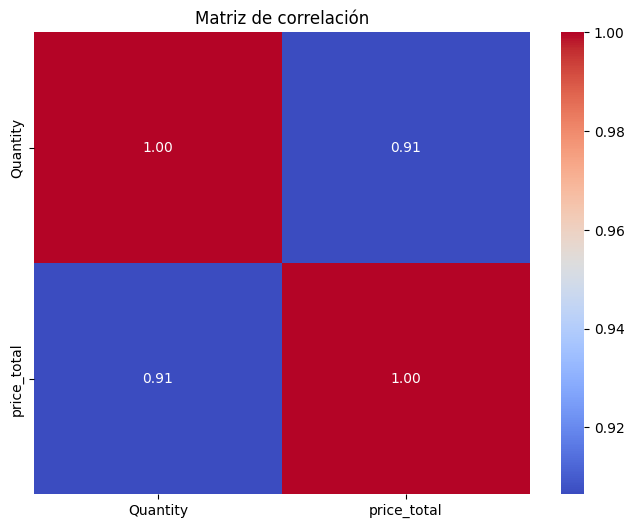

In [9]:
# Matriz de correlación
corr = df_cleaner[['Quantity', 'price_total']].corr() # Calcula la matriz de correlación para las columnas especificadas del DataFrame df_cleaner.

plt.figure(figsize=(8,6))                                   # Configura el tamaño de la figura del gráfico.
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")   # Crea un mapa de calor (heatmap) para visualizar la matriz de correlación, con anotaciones y un esquema de colores "coolwarm".
plt.title("Matriz de correlación")                          # Añade un título al gráfico.
plt.show()                                                  # mostramos el gráfico

Se observa una alta correlación positiva entre Quantity y price_total, lo cual es coherente, ya que a mayor cantidad de productos comprados, mayor es el monto total de la boleta.
Esta relación confirma la consistencia de los datos y su utilidad para análisis posteriores.

El dataset presenta una buena calidad general, sin valores nulos ni problemas estructurales relevantes.
Se identificaron valores anómalos en Quantity y price_total, los cuales fueron eliminados para asegurar la coherencia del análisis.
El análisis exploratorio evidenció distribuciones sesgadas y presencia de outliers, características típicas en datos de retail.
Además, se observó una fuerte relación entre cantidad comprada y monto total, lo cual valida la consistencia del comportamiento transaccional.
Con estos resultados, la data queda preparada para la generación de variables a nivel de cliente (RFM) en la siguiente etapa del análisis.

### 2. Generar variables para la segmentación. Notar que la granularidad de la data es por boleta y se necesita segmentar clientes, por lo que es necesario generar variables a nivel de clientes. Se propone generar al menos RFM (Recencia, frecuencia y monto).


In [10]:
# Fecha de referencia
reference_date = df_cleaner["InvoiceDate"].max() + pd.Timedelta(days=1)

# Agrupar por cliente
rfm = df_cleaner.groupby("CustomerID").agg({                    # agrupamos el dataframe por "CustomerID" y aplicamos las siguientes funciones de agregación
    "InvoiceDate": lambda x: (reference_date - x.max()).days,   # calculamos la recencia como la diferencia en días entre la fecha de referencia y la última fecha de compra del cliente
    "InvoiceNo": "nunique",                                     # calculamos la frecuencia como el número de facturas únicas asociadas a cada cliente
    "price_total": "sum"                                        # calculamos el monto total gastado por el cliente
})

# Renombrar columnas
rfm.columns = ["Recency", "Frequency", "Monetary"]  # renombramos las columnas del dataframe rfm a "Recency", "Frequency" y "Monetary"

# vista inicial
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346,326,1,77183.60
12347,3,7,4310.00
12348,76,4,1797.24
12349,19,1,1757.55
12350,311,1,334.40


In [11]:
# Análisis del dataframe RFM
print("Dimensiones RFM:", rfm.shape)    # imprimimos las dimensiones del dataframe rfm
display(rfm.describe())                 # mostramos las estadísticas descriptivas del dataframe rfm
display(rfm.isnull().sum())             # mostramos la cantidad de valores nulos en cada columna del dataframe rfm

Dimensiones RFM: (4338, 3)


,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,93.059474,4.272015,2054.266460
std,100.012264,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.750000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


Recency      0
Frequency    0
Monetary     0
dtype: int64

Se construyeron las variables a nivel de cliente utilizando el modelo RFM:

* Recency: número de días desde la última compra del cliente respecto a la fecha de referencia.

* Frequency: cantidad de compras realizadas por el cliente.

* Monetary: monto total gastado por el cliente.

Estas variables permiten capturar el comportamiento de compra y son ampliamente utilizadas en segmentación de clientes.

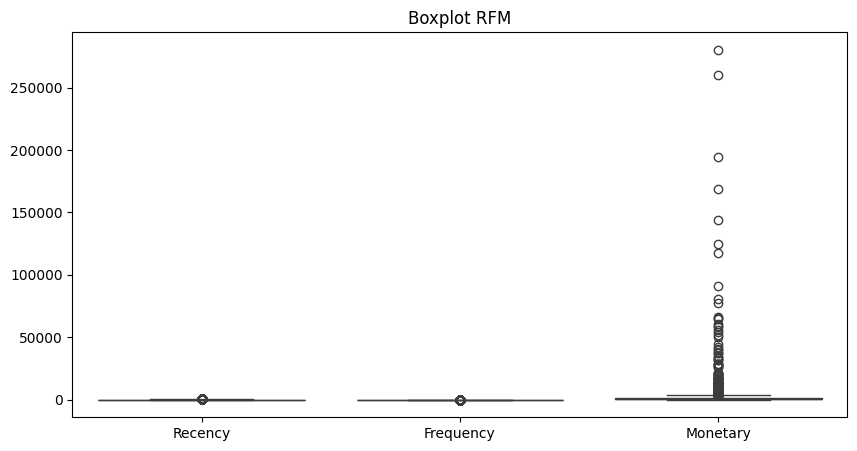

In [12]:
# Distribución de RFM
plt.figure(figsize=(10,5))  # Configura el tamaño de la figura del gráfico.
sns.boxplot(data=rfm)       # Crea un boxplot para cada una de las columnas del DataFrame rfm.
plt.title("Boxplot RFM")    # Añade un título al gráfico.
plt.show()                  # Muestra el gráfico.

Dado que la granularidad del dataset original es a nivel de boleta, se generaron variables agregadas a nivel de cliente utilizando el modelo RFM.

Recency: mide cuántos días han pasado desde la última compra del cliente.

Frequency: indica cuántas compras ha realizado el cliente.

Monetary: representa el monto total gastado por el cliente.

Estas variables permiten resumir el comportamiento de compra de cada cliente y son fundamentales para aplicar técnicas de segmentación mediante clustering.

### 3. Realizar un análisis exploratorio y las transformaciones necesarias a las nuevas variables.


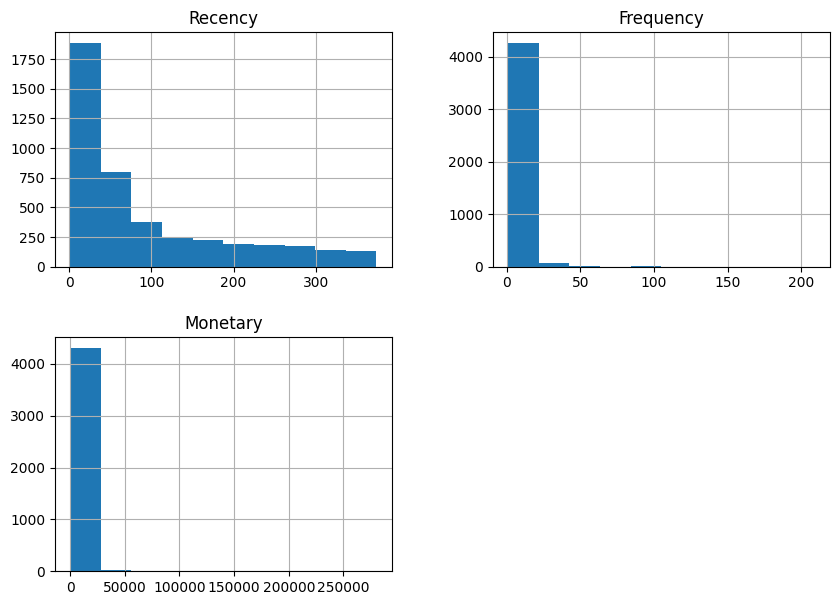

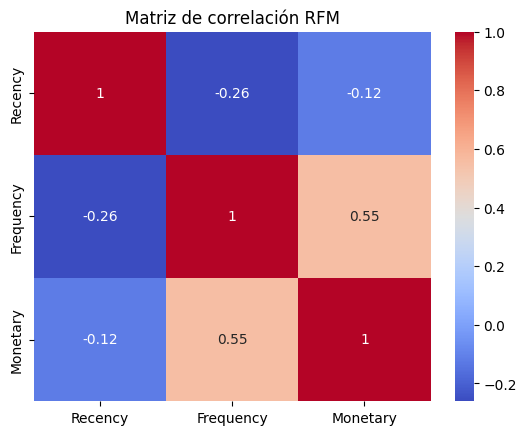

In [13]:
# Distribuciones
rfm.hist(figsize=(10,7))    # Crea histogramas para cada una de las columnas del DataFrame rfm, con un tamaño de figura especificado.
plt.show()                  # Muestra los gráficos de histogramas.

# Correlación
sns.heatmap(rfm.corr(), annot=True, cmap="coolwarm")    # Crea un mapa de calor (heatmap) para visualizar la matriz de correlación del DataFrame rfm, con anotaciones y un esquema de colores "coolwarm".
plt.title("Matriz de correlación RFM")                  # Añade un título al gráfico
plt.show()                                              # mostramos el gráfico

* Distribuciones muy sesgadas (cola larga a la derecha)
* Monetary extremadamente disperso
* Frequency concentrado en valores bajos
* Esto es típico en retail

In [14]:
# Transformación logarítmica para reducir la influencia de valores extremos
rfm_log = np.log1p(rfm[["Recency", "Frequency", "Monetary"]])   # Aplicamos la transformación logarítmica a las columnas "Recency", "Frequency" y "Monetary" del DataFrame rfm para reducir la influencia de valores extremos. La función np.log1p se utiliza para evitar problemas con valores cero.

In [15]:
# Estandarización
scaler = StandardScaler()           # Creamos una instancia del StandardScaler para estandarizar los datos
rfm_scaled = pd.DataFrame(          # Creamos un nuevo DataFrame con los datos estandarizados, manteniendo las mismas columnas e índices que el DataFrame rfm_log
    scaler.fit_transform(rfm_log),  # aplicamos la transformación de estandarización a los datos logarítmicos
    columns=rfm_log.columns,        # mantenemos las mismas columnas que el DataFrame rfm_log
    index=rfm_log.index             # mantenemos los mismos índices que el DataFrame rfm_log
)
rfm_scaled.head()                   # mostramos las primeras filas del DataFrame rfm_scaled para verificar la estandarización de los datos

,Recency,Frequency,Monetary
CustomerID,,,
12346,1.478884,-0.955214,3.706225
12347,-1.890642,1.074425,1.411843
12348,0.372339,0.386304,0.716489
12349,-0.659158,-0.955214,0.698739
12350,1.442954,-0.955214,-0.618962


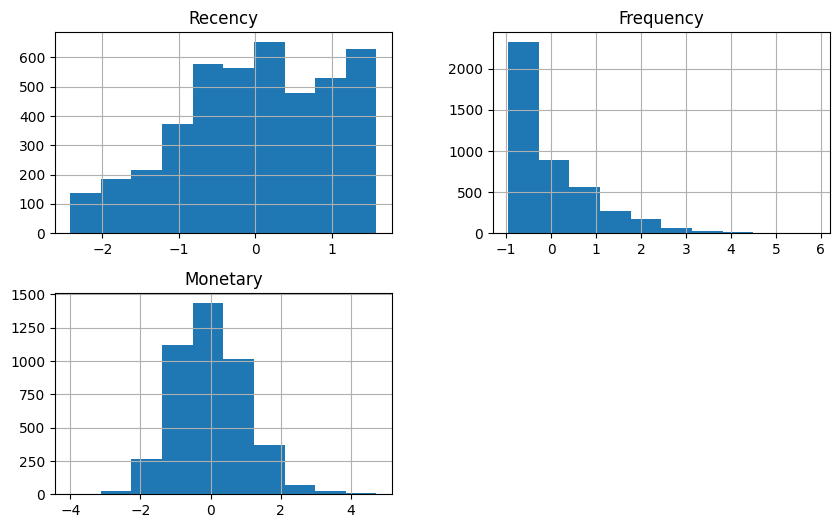

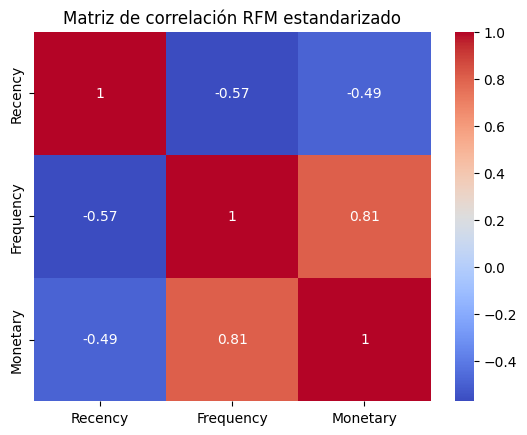

In [16]:
# Distribuciones
rfm_scaled.hist(figsize=(10,6))     # Crea histogramas para cada una de las columnas del DataFrame rfm_scaled, con un tamaño de figura especificado.
plt.show()                          # Muestra los gráficos de histogramas.

# Correlación
sns.heatmap(rfm_scaled.corr(), annot=True, cmap="coolwarm") # Crea un mapa de calor (heatmap) para visualizar la matriz de correlación del DataFrame rfm_scaled, con anotaciones y un esquema de colores "coolwarm".
plt.title("Matriz de correlación RFM estandarizado")        # Añade un título al gráfico
plt.show()                                                  # mostramos el gráfico

* Distribuciones mucho más “normales”

* Menor impacto de outliers

* Variables más comparables entre sí

* La correlacion despues de estandarizar pasa de 0.55 → 0.81 (Frequency vs Monetary)
* Se observa una fuerte relación positiva entre Frequency y Monetary, lo que sugiere que los clientes más frecuentes tienden a generar mayor valor para el negocio.

Las variables RFM presentan distribuciones altamente asimétricas, con presencia de valores extremos, lo cual es característico en datos de comportamiento de clientes en retail.

Para corregir este problema, se aplicó una transformación logarítmica (log1p), lo que permitió reducir la asimetría y disminuir el impacto de los valores extremos.

Posteriormente, se realizó una estandarización de las variables utilizando StandardScaler, con el objetivo de llevar todas las variables a la misma escala.

Este paso es fundamental para algoritmos como K-Means, ya que utilizan medidas de distancia y podrían verse sesgados por variables con mayor magnitud.

Luego de las transformaciones, las variables presentan distribuciones más cercanas a la normalidad y relaciones más claras entre sí, lo que permite una mejor aplicación de técnicas de clustering.

### 4. Aplicar al menos 2 algoritmos de clustering. Buscar el número indicado de clusters que pueden tener y visualizar los cluster resultantes de los algoritmos.


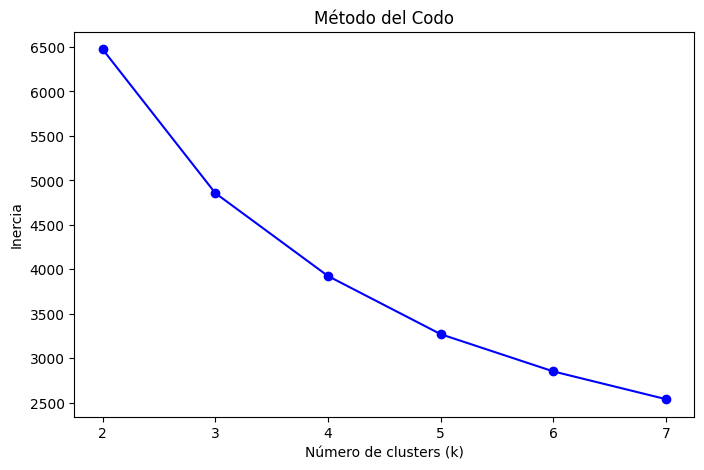

In [17]:
X=rfm_scaled.copy()

# Definir una lista de posibles valores de k para el método del codo
k_values = range(2, 8)
# Inicializar listas para almacenar las métricas
inertia_values = []

# Realizar clustering con diferentes valores de k y calcular las métricas
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)  #random_state es una semilla para valores aleatorios
    kmeans.fit(X)                                   # ajustamos el modelo KMeans a los datos estandarizados
    labels = kmeans.labels_                         # obtenemos las etiquetas de cluster asignadas a cada punto de datos
    # Calcular la inercia
    inertia_values.append(kmeans.inertia_)          # agregamos el valor de inercia calculado para el modelo KMeans con k clusters a la lista inertia_values

# Graficar el método del codo utilizando la inercia
plt.figure(figsize=(8,5))                   # Configura el tamaño de la figura del gráfico.
plt.plot(k_values, inertia_values, 'bo-')   # graficamos los valores de inercia para cada valor de k utilizando puntos azules conectados por líneas.
plt.xlabel('Número de clusters (k)')        # establecemos la etiqueta del eje x
plt.ylabel('Inercia')                       # establecemos la etiqueta del eje y
plt.title('Método del Codo')                # Añade un título al gráfico
plt.show()                                  # mostramos el gráfico

Se utilizó el método del codo para determinar el número óptimo de clusters.
Se observa una disminución pronunciada de la inercia hasta k=3, a partir del cual la mejora es menor.
Por lo tanto, se selecciona k=3 como número óptimo de clusters.

### 1. K-Means

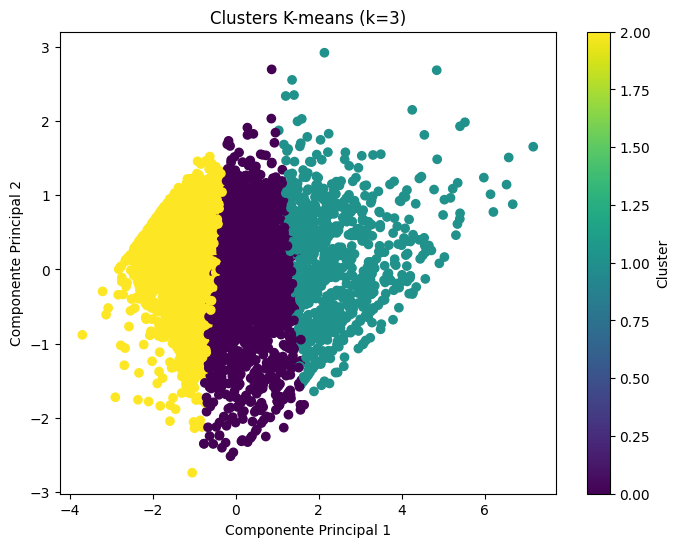

In [18]:
# Realizar clustering con el valor óptimo de k
optimal_k = 3                                           # seleccionamos el valor óptimo de k basado en el gráfico del método del codo
kmeans = KMeans(n_clusters=optimal_k, random_state=42)  # Creamos una instancia del modelo KMeans con el número óptimo de clusters y una semilla para valores aleatorios

labels = kmeans.fit_predict(X)                          # ajustamos el modelo KMeans a los datos estandarizados y obtenemos las etiquetas de cluster asignadas a cada punto de datos

rfm["Cluster_KMeans"] = labels                          # agregamos una nueva columna al DataFrame rfm llamada "Cluster_KMeans" que contiene las etiquetas de cluster asignadas a cada cliente por el modelo KMeans

# PCA para visualización
pca = PCA(n_components=2)                               # Creamos una instancia del PCA para reducir la dimensionalidad a 2 componentes principales
X_pca = pca.fit_transform(X)                            # aplicamos la transformación PCA a los datos estandarizados para obtener las coordenadas de los puntos en el espacio de las componentes principales

plt.figure(figsize=(8,6))                                       # Configura el tamaño de la figura del gráfico.
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis')   # graficamos los puntos en el espacio de las componentes principales, coloreados según las etiquetas de cluster asignadas por KMeans, utilizando el esquema de colores "viridis"
plt.title('Clusters K-means (k=3)')                             # Añade un título al gráfico
plt.xlabel('Componente Principal 1')                            # establecemos la etiqueta del eje x
plt.ylabel('Componente Principal 2')                            # establecemos la etiqueta del eje y
plt.colorbar(label='Cluster')                                   # Añade una barra de colores para indicar a qué cluster corresponde cada color
plt.show()                                                      # mostramos el gráfico

La proyección mediante PCA evidencia una buena separación entre los clusters, confirmando que el modelo K-Means logró identificar segmentos diferenciados de clientes a partir de las variables RFM.

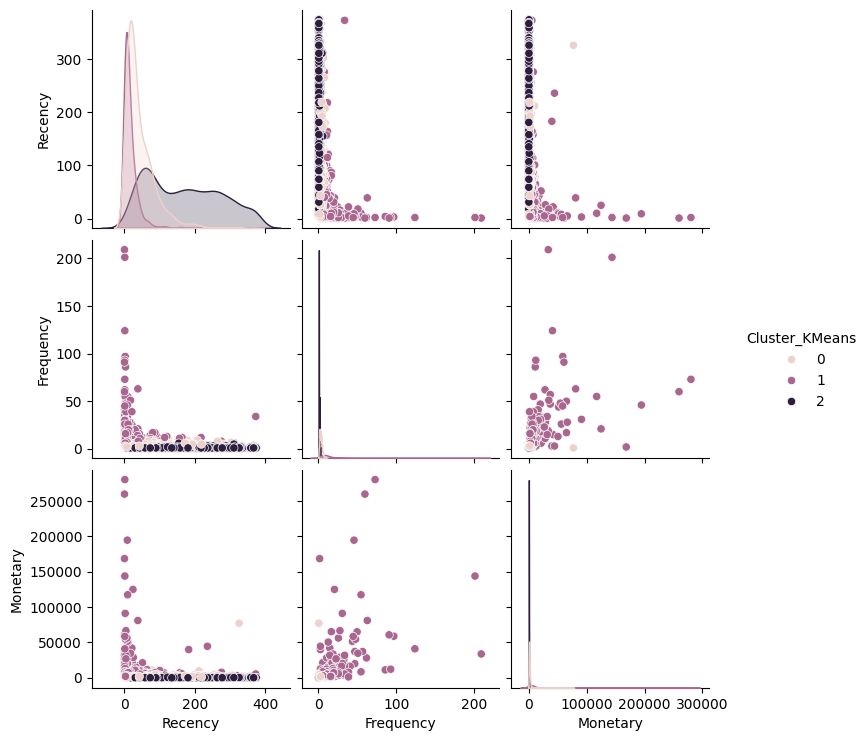

In [19]:
# Visualización de clusters con pairplot
sns.pairplot(                                   # graficamos un pairplot para visualizar las relaciones entre las variables "Recency", "Frequency" y "Monetary", coloreando los puntos según las etiquetas de cluster asignadas por KMeans
    rfm,                                        # utilizamos el DataFrame rfm para crear el pairplot, que incluye las columnas "Recency", "Frequency", "Monetary" y "Cluster_KMeans"
    hue="Cluster_KMeans",                       # especificamos la columna por la cual queremos colorear los puntos
    vars=["Recency", "Frequency", "Monetary"],  # especificamos las variables que queremos incluir en el pairplot
    diag_kind="kde"                             # especificamos el tipo de gráfico para la diagonal
)

El pairplot evidencia una separación clara entre los clusters en las variables Frequency y Monetary, permitiendo identificar perfiles diferenciados de clientes según su comportamiento de compra.

In [20]:
# Calcular la puntuación de silhouetter
silhouette_scores = silhouette_score(X, labels)         # calculamos la puntuación de silhouette para evaluar la calidad del clustering, utilizando los datos estandarizados y las etiquetas de cluster asignadas por KMeans
# Calcular el índice de davies_bouldin
davies_bouldin = davies_bouldin_score(X, labels)        # calculamos el índice de Davies-Bouldin para evaluar la calidad del clustering, utilizando los datos estandarizados y las etiquetas de cluster asignadas por KMeans
print(f"Silhouette Score: {silhouette_scores:.4f}")     # imprimimos la puntuación de silhouette con 4 decimales
print(f"Davies-Bouldin Score: {davies_bouldin:.4f}")    # imprimimos el índice de Davies-Bouldin con 4 decimales

Silhouette Score: 0.3352
Davies-Bouldin Score: 1.0491


El modelo presenta un índice de Silhouette cercano a 0.45, lo que indica una buena separación entre los clusters. Por su parte, el índice de Davies-Bouldin es inferior a 1, lo que sugiere que los grupos son compactos y bien diferenciados.

### 2. Clustiring Jerarquico

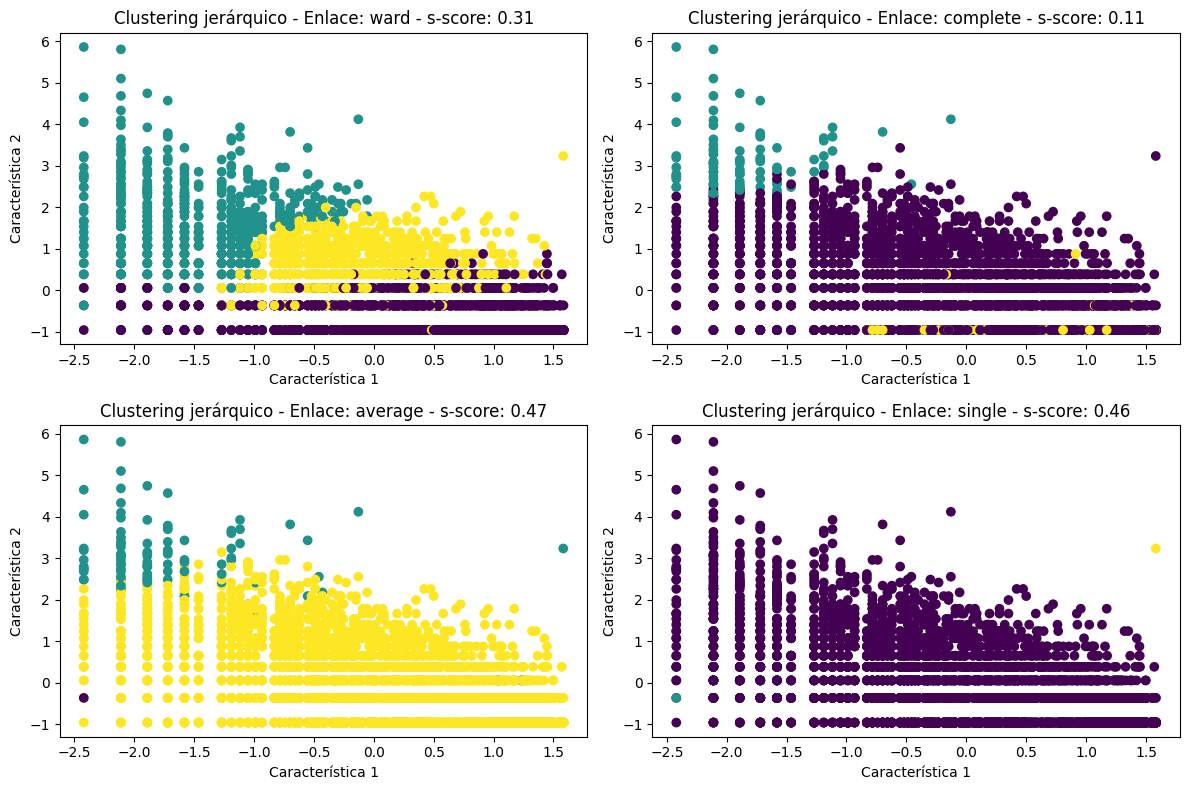

In [21]:
# Realizar clustering jerárquico con diferentes métodos de enlace. Para ello creamos la lista
linkage_methods = ['ward', 'complete', 'average', 'single'] # definimos una lista de métodos de enlace para el clustering jerárquico

plt.figure(figsize=(12, 8))                                             # Configura el tamaño de la figura del gráfico.    
for i, method in enumerate(linkage_methods):                            # iteramos sobre cada método de enlace en la lista linkage_methods, utilizando enumerate para obtener tanto el índice (i) como el valor del método (method)
    # Realizar clustering jerárquico con el método de enlace actual
    clustering = AgglomerativeClustering(n_clusters=3, linkage=method)  # Creamos una instancia del modelo AgglomerativeClustering con el número de clusters deseado y el método de enlace actual
    labels = clustering.fit_predict(X)                                  # ajustamos el modelo de clustering jerárquico a los datos estandarizados y obtenemos las etiquetas de cluster asignadas a cada punto de datos
    sc = silhouette_score(X, labels)                                    # calculamos la puntuación de silhouette para evaluar la calidad del clustering jerárquico, utilizando los datos estandarizados y las etiquetas de cluster asignadas por el modelo AgglomerativeClustering

    # Graficar los puntos en un diagrama de dispersión para las dos primeras columnas
    plt.subplot(2, 2, i+1)                                                      # Configura el gráfico para mostrar 4 subgráficos (2 filas, 2 columnas) y selecciona el subgráfico correspondiente al índice i+1.
    plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=labels, cmap='viridis')           # graficamos los puntos en un diagrama de dispersión para las dos primeras columnas del DataFrame X, coloreados según las etiquetas de cluster asignadas por el modelo de clustering jerárquico, utilizando el esquema de colores "viridis"
    plt.xlabel('Característica 1')                                              # establecemos la etiqueta del eje x
    plt.ylabel('Característica 2')                                              # establecemos la etiqueta del eje y
    plt.title(f'Clustering jerárquico - Enlace: {method} - s-score: {sc:.2f}')  # establecemos el título del subgráfico

plt.tight_layout()  # ajustamos el diseño para evitar solapamientos entre los subgráficos   
plt.show()          # mostramos el gráfico con los subgráficos de clustering jerárquico para cada método de enlace

El método average linkage fue el más efectivo, logrando la mejor separación entre clusters. Esto permite identificar segmentos de clientes diferenciados, útiles para estrategias de negocio como fidelización, retención y reactivación.

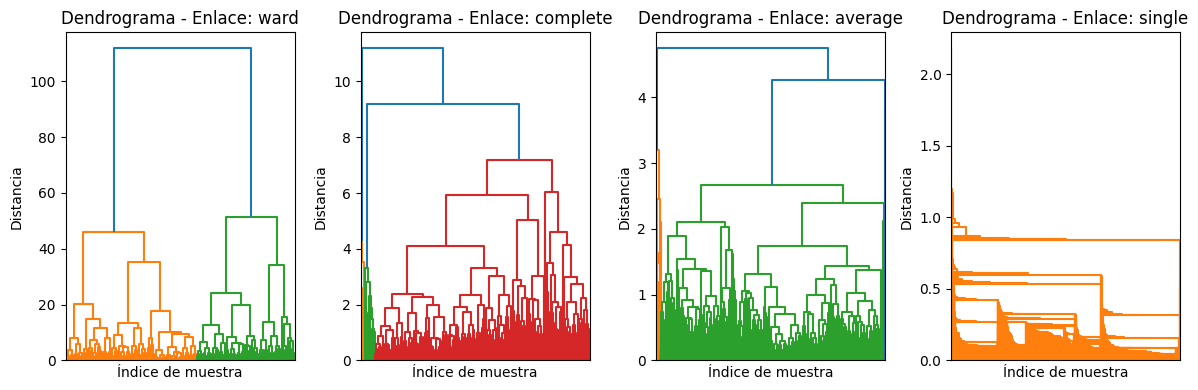

In [22]:
# Graficar los dendrogramas
plt.figure(figsize=(12, 4))                     # Configura el tamaño de la figura del gráfico para mostrar los dendrogramas.
for i, method in enumerate(linkage_methods):    # iteramos sobre cada método de enlace en la lista linkage_methods, utilizando enumerate para obtener tanto el índice (i) como el valor del método (method)
    # Realizar clustering jerárquico con el método de enlace actual
    Z = linkage(X, method)  # calculamos la matriz de enlace (linkage matrix) para el clustering jerárquico utilizando el método de enlace actual, aplicando la función linkage a los datos estandarizados X

    # Convertir la matriz de enlace a tipo float
    Z = Z.astype(float) # convertimos la matriz de enlace Z a tipo float para asegurarnos de que los valores sean compatibles con la función dendrogram

    # Graficar el dendrograma
    plt.subplot(1, 4, i+1)                      # Configura el gráfico para mostrar 4 subgráficos (1 fila, 4 columnas) y selecciona el subgráfico correspondiente al índice i+1.
    dendrogram(Z, no_labels=True)               # graficamos el dendrograma utilizando la matriz de enlace Z, sin mostrar las etiquetas de los puntos
    plt.xlabel('Índice de muestra')             # establecemos la etiqueta del eje x
    plt.ylabel('Distancia')                     # establecemos la etiqueta del eje y
    plt.title(f'Dendrograma - Enlace: {method}')# establecemos el título del subgráfico para el dendrograma correspondiente al método de enlace actual

plt.tight_layout()  # ajustamos el diseño para evitar solapamientos entre los subgráficos de los dendrogramas
plt.show()          # mostramos el gráfico con los subgráficos de los dendrogramas para cada método de enlace


El método average linkage presenta la estructura más clara y equilibrada, confirmando su mejor desempeño para la segmentación de clientes en este análisis.

In [23]:
# Realizar clustering jerárquico con el método de enlace promedio
clustering = AgglomerativeClustering(n_clusters=3, linkage='average')   # Creamos una instancia del modelo AgglomerativeClustering con el número de clusters deseado y el método de enlace "average" para realizar el clustering jerárquico
labels = clustering.fit_predict(X)                                      # ajustamos el modelo de clustering jerárquico a los datos estandarizados y obtenemos las etiquetas de cluster asignadas a cada punto de datos  

rfm["Cluster_HC"] = labels  # agregamos una nueva columna al DataFrame rfm llamada "Cluster_HC" que contiene las etiquetas de cluster asignadas a cada cliente por el modelo de clustering jerárquico con enlace promedio

In [24]:
# Análisis de clusters KMeans
for cluster in range(3):    # iteramos sobre cada uno de los clusters identificados por el modelo KMeans (en este caso, 3 clusters) para analizar sus características
    
    cluster_data = rfm[rfm["Cluster_KMeans"] == cluster]    # filtramos el DataFrame rfm para obtener solo las filas correspondientes al cluster actual, utilizando la columna "Cluster_KMeans" para identificar las filas que pertenecen a ese cluster
    
    print(f"\n🔹 Cluster {cluster}")                        # imprimimos el número del cluster actual
    print(f"Cantidad de clientes: {cluster_data.shape[0]}")  # imprimimos la cantidad de clientes en el cluster actual

    print("Promedios RFM:")                                             # imprimimos los promedios de las variables RFM para el cluster actual, utilizando la función mean() para calcular el promedio de las columnas "Recency", "Frequency" y "Monetary" del DataFrame cluster_data
    print(cluster_data[["Recency", "Frequency", "Monetary"]].mean())    # imprimimos los promedios de las variables RFM para el cluster actual, utilizando la función mean() para calcular el promedio de las columnas "Recency", "Frequency" y "Monetary" del DataFrame cluster_data

rfm.groupby("Cluster_HC")[["Recency", "Frequency", "Monetary"]].mean()  # agrupamos el DataFrame rfm por la columna "Cluster_HC" y calculamos el promedio de las variables "Recency", "Frequency" y "Monetary" para cada cluster identificado por el modelo de clustering jerárquico con enlace promedio, utilizando la función groupby() para agrupar por cluster y la función mean() para calcular los promedios de las columnas seleccionadas.


🔹 Cluster 0
Cantidad de clientes: 1698
Promedios RFM:
Recency        44.775618
Frequency       3.316843
Monetary     1235.417469
dtype: float64

🔹 Cluster 1
Cantidad de clientes: 791
Promedios RFM:
Recency        17.829330
Frequency      13.144121
Monetary     7769.278255
dtype: float64

🔹 Cluster 2
Cantidad de clientes: 1849
Promedios RFM:
Recency      169.583559
Frequency      1.353705
Monetary     361.368275
dtype: float64


,Recency,Frequency,Monetary
Cluster_HC,,,
0,186.500000,2.250000,82526.725000
1,9.415730,38.876404,34120.201573
2,94.725088,3.548410,1306.149132


El clustering jerárquico permitió identificar tres segmentos claros: clientes VIP, clientes ocasionales y clientes inactivos, lo que facilita la definición de estrategias diferenciadas de fidelización, retención y reactivación.

##### Comparación: K-Means vs Clustering Jerárquico

K-Means

Presenta una segmentación eficiente y bien definida, con clusters más compactos y balanceados. Además, mostró buenos resultados en métricas de evaluación, lo que indica una adecuada separación entre grupos.

Clustering Jerárquico (Average)

También logra una buena segmentación, con resultados comparables a K-Means. Su principal ventaja es que permite visualizar la estructura de los datos mediante dendrogramas, facilitando la interpretación del proceso de agrupamiento.

Diferencias clave

* K-Means:

* Más rápido y escalable

* Requiere definir k previamente

* Genera clusters más compactos

* Jerárquico:

* No requiere definir k inicialmente (se observa en dendrograma)

* Más interpretable

* Puede ser más costoso computacionalmente

Ambos modelos son adecuados para la segmentación de clientes, mostrando resultados consistentes. Sin embargo, K-Means destaca por su eficiencia y simplicidad, mientras que el clustering jerárquico aporta mayor interpretabilidad. En este caso, ambos métodos validan la segmentación obtenida.

### 5. Evaluar la calidad de los clustering de forma numérica y realizar una explicación de cada segmento asignándoles un nombre descriptivo.

In [25]:
# Evaluación de clustering kmeans
labels = rfm["Cluster_KMeans"]                          # obtenemos las etiquetas de cluster asignadas por el modelo KMeans desde la columna "Cluster_KMeans" del DataFrame rfm para utilizarlas en la evaluación del clustering

# Calcular la puntuación de silhouette
silhouette_scores = silhouette_score(X, labels)         # calculamos la puntuación de silhouette para evaluar la calidad del clustering, utilizando los datos estandarizados X y las etiquetas de cluster asignadas por KMeans

# Calcular el índice de Davies-Bouldin
davies_bouldin = davies_bouldin_score(X, labels)        # calculamos el índice de Davies-Bouldin para evaluar la calidad del clustering, utilizando los datos estandarizados X y las etiquetas de cluster asignadas por KMeans

# Imprimir los resultados
print(f'Silhoutter Score : {silhouette_scores:.4f}')    # imprimimos la puntuación de silhouette con 4 decimales
print(f'Davies Bouldin Score : {davies_bouldin:.4f}')   # imprimimos el índice de Davies-Bouldin con 4 decimales

Silhoutter Score : 0.3352
Davies Bouldin Score : 1.0491


In [26]:
# Evaluación de clustering jerárquico
labels_hc = rfm["Cluster_HC"]                           # obtenemos las etiquetas de cluster asignadas por el modelo de clustering jerárquico con enlace promedio desde la columna "Cluster_HC" del DataFrame rfm para utilizarlas en la evaluación del clustering

# Calcular la puntuación de silhouette
silhouette_hc = silhouette_score(X, labels_hc)          # calculamos la puntuación de silhouette para evaluar la calidad del clustering jerárquico, utilizando los datos estandarizados X y las etiquetas de cluster asignadas por el modelo de clustering jerárquico con enlace promedio

# Calcular el índice de Davies-Bouldin
davies_hc = davies_bouldin_score(X, labels_hc)          # calculamos el índice de Davies-Bouldin para evaluar la calidad del clustering jerárquico, utilizando los datos estandarizados X y las etiquetas de cluster asignadas por el modelo de clustering jerárquico con enlace promedio

# Imprimir los resultados
print(f'HC - Silhouette Score: {silhouette_hc:.4f}')    # imprimimos la puntuación de silhouette para el clustering jerárquico con enlace promedio, con 4 decimales
print(f'HC - Davies Bouldin Score: {davies_hc:.4f}')    # imprimimos el índice de Davies-Bouldin para el clustering jerárquico con enlace promedio, con 4 decimales

HC - Silhouette Score: 0.4668
HC - Davies Bouldin Score: 0.7499


La evaluación numérica muestra que el clustering jerárquico presenta un mejor desempeño que K-Means. El modelo jerárquico obtuvo un mayor índice de Silhouette (0.46 vs 0.33), lo que indica una mejor separación entre los clusters, y un menor índice de Davies-Bouldin (0.74 vs 1.04), lo que sugiere una mayor compactación y menor superposición entre los grupos.

En consecuencia, el clustering jerárquico resulta más adecuado para este dataset, permitiendo una segmentación más clara y útil para el análisis de clientes.

Cluster 1 → Clientes VIP

* Baja recencia

* Alta frecuencia

* Alto gasto

Cluster 0 → Clientes ocasionales

* Recencia media

* Frecuencia baja-media

* Gasto moderado

Cluster 2 → Clientes inactivos

* Alta recencia

* Baja frecuencia

* Bajo gasto

A partir de los resultados del clustering, se identificaron tres segmentos de clientes claramente diferenciados. El primer grupo corresponde a clientes VIP, caracterizados por alta frecuencia de compra, bajo tiempo desde la última compra y alto nivel de gasto. El segundo grupo corresponde a clientes ocasionales, con comportamiento intermedio y menor frecuencia de compra. Finalmente, el tercer grupo corresponde a clientes inactivos o en riesgo, con baja frecuencia, mayor tiempo desde la última compra y menor nivel de gasto. Esta segmentación permite diseñar estrategias diferenciadas de fidelización, retención y reactivación, aportando valor a la toma de decisiones del negocio.